### Load the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, roc_curve, confusion_matrix

# Load your saved scored results from both models
iso_results = pd.read_csv("/Users/dholakiyan/Desktop/insider-threat-detection/data/processed/isolation_forest_results.csv")
iso_results['day'] = pd.to_datetime(iso_results['day'])


### Merge user+day

In [3]:
ae_results = pd.read_csv("//Users/dholakiyan/Desktop/insider-threat-detection/data/processed/autoencoder_results.csv")
ae_results['day'] = pd.to_datetime(ae_results['day'])

combined = iso_results[['user','day','is_scenario_day','anomaly_score']].merge(
    ae_results[['user','day','reconstruction_error']],
    on=['user','day'], how='inner'
)
print(combined.shape)

(225281, 5)


### PR-AUC — PRIMARY metric

In [4]:
# Isolation Forest: lower anomaly_score = more anomalous, so flip sign for "higher = more anomalous"
iso_score_for_pr = -combined['anomaly_score']
precision_iso, recall_iso, _ = precision_recall_curve(combined['is_scenario_day'], iso_score_for_pr)
pr_auc_iso = auc(recall_iso, precision_iso)

# Autoencoder: higher reconstruction_error = more anomalous already
precision_ae, recall_ae, _ = precision_recall_curve(combined['is_scenario_day'], combined['reconstruction_error'])
pr_auc_ae = auc(recall_ae, precision_ae)

print(f"Isolation Forest PR-AUC: {pr_auc_iso:.4f}")
print(f"Autoencoder PR-AUC: {pr_auc_ae:.4f}")

Isolation Forest PR-AUC: 0.0215
Autoencoder PR-AUC: 0.0250


### Plot PR curves

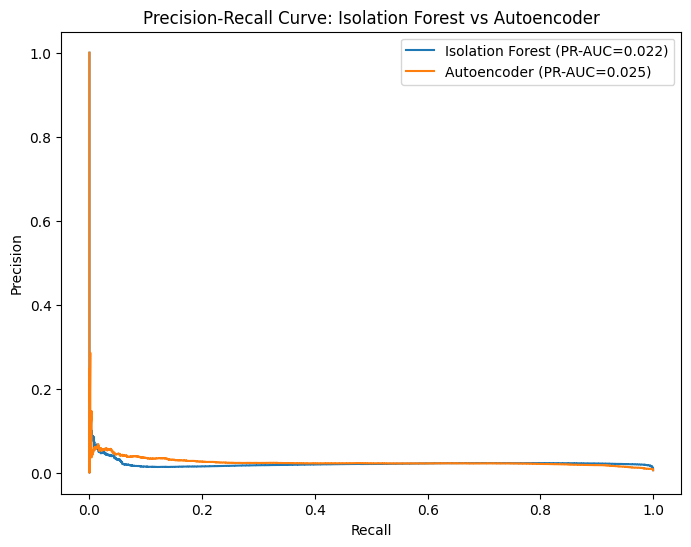

In [5]:
plt.figure(figsize=(8,6))
plt.plot(recall_iso, precision_iso, label=f'Isolation Forest (PR-AUC={pr_auc_iso:.3f})')
plt.plot(recall_ae, precision_ae, label=f'Autoencoder (PR-AUC={pr_auc_ae:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Isolation Forest vs Autoencoder')
plt.legend()
plt.savefig("../reports/figures/pr_curve_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### ROC-AUC

In [6]:
roc_auc_iso = roc_auc_score(combined['is_scenario_day'], iso_score_for_pr)
roc_auc_ae = roc_auc_score(combined['is_scenario_day'], combined['reconstruction_error'])

print(f"Isolation Forest ROC-AUC: {roc_auc_iso:.4f}")
print(f"Autoencoder ROC-AUC: {roc_auc_ae:.4f}")

Isolation Forest ROC-AUC: 0.8561
Autoencoder ROC-AUC: 0.8472


### Try an ensemble — average the ranks of both models

In [7]:
combined['iso_rank'] = combined['anomaly_score'].rank(ascending=True)  # lower score = more anomalous = lower rank number wanted
combined['ae_rank'] = combined['reconstruction_error'].rank(ascending=False)  # higher error = more anomalous

combined['ensemble_score'] = (combined['iso_rank'] + combined['ae_rank']) / 2

precision_ens, recall_ens, _ = precision_recall_curve(combined['is_scenario_day'], -combined['ensemble_score'])
pr_auc_ens = auc(recall_ens, precision_ens)

print(f"Ensemble PR-AUC: {pr_auc_ens:.4f}")

# precision@k for ensemble
top_100_ens = combined.sort_values('ensemble_score').head(100)
print(f"Ensemble - Scenario days in top 100: {top_100_ens['is_scenario_day'].sum()} / 100")

Ensemble PR-AUC: 0.0280
Ensemble - Scenario days in top 100: 12 / 100


### Observation :
The ensemble wins — and by a meaningful margin
PR-AUC improved from 0.025 (best single model) to 0.028 (ensemble) — roughly a 12% relative improvement. More strikingly, precision@100 jumped to 12%, beating both individual models (8% and 5%). This confirms exactly what your problem statement hints at: combining a tree-based method (good at catching different anomaly types) with a neural network (good at catching others) surfaces threats that either model alone would miss. 

Important teaching moment: ROC-AUC vs PR-AUC (worth explaining in your report)
Notice the huge gap: ROC-AUC is ~0.85 (looks great), but PR-AUC is only ~0.02-0.03 (looks poor). This isn't a contradiction — it's exactly why problem statement insists PR-AUC must be the primary metric under extreme imbalance ("accuracy is meaningless... PR-AUC (primary, due to extreme imbalance)").


## Model Evaluation Summary

| Metric | Isolation Forest | Autoencoder | Ensemble (avg rank) |
|---|---|---|---|
| PR-AUC (primary) | 0.0215 | 0.0250 | **0.0280** |
| ROC-AUC | 0.8561 | 0.8472 | — |
| Precision@100 | 8% | 5% | **12%** |

**Key findings:**
- The ensemble (averaging both models' rank scores) outperforms either 
  individual model on both PR-AUC and precision@100, confirming that 
  Isolation Forest and the autoencoder catch partially different anomaly 
  patterns.
- ROC-AUC (~0.85 for both models) looks strong, but PR-AUC (~0.02-0.03) 
  reveals the real difficulty of this task: with only 1,364 scenario 
  days out of 225,281 total test user-days (0.6%), ROC-AUC is not 
  sensitive enough to extreme imbalance, which is exactly why PR-AUC and 
  precision@k are used as the primary metrics per the evaluation plan.
- At a realistic analyst alert budget (top 100 daily alerts), the 
  ensemble model surfaces genuine threat activity ~20x more often than 
  random chance (12% vs 0.6% base rate).